# Simulation DGP comparison diagnostics

This notebook is a diagnostic companion to the existing simulation work. It does not modify the capital-allocation, PTO, black-box, or DFL code. Its purpose is to compare the original independent Gaussian-mixture charge-off DGP with a proposed autoregressive Gaussian-mixture DGP using the same macro path, the same stress-probability path, the same sample length, and reproducible random seeds.

## 1. Imports, paths, and calibrated parameters

In [146]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.6f}".format)

SEED_MACRO = 42
SEED_INDEPENDENT = 20260624
SEED_AR = 20260625
SAMPLE_LENGTH = 500

mu_N = 0.0061
sigma_N = 0.0042
mu_S = 0.0143
sigma_S = 0.0067
rho = 0.7

MACRO_NAMES = ["activity", "labour_market_stress", "financial_conditions"]
A = np.array(
    [
        [0.78, -0.05, -0.04],
        [-0.04, 0.72, 0.10],
        [-0.03, 0.12, 0.70],
    ],
    dtype=float,
)
shock_cov = np.array(
    [
        [0.30, -0.08, -0.06],
        [-0.08, 0.25, 0.09],
        [-0.06, 0.09, 0.28],
    ],
    dtype=float,
)
gamma_0 = -1.75
gamma = np.array([-0.85, 0.95, 0.85], dtype=float)



def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")

REPO_ROOT = find_repo_root()
FIGURE_DIR = REPO_ROOT / "models" / "simulation" / "figures" / "dgp_diagnostics"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print("Shared macro/probability path: generated inside this notebook")
print(f"Figure output directory: {FIGURE_DIR.relative_to(REPO_ROOT)}")

Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Shared macro/probability path: generated inside this notebook
Figure output directory: models/simulation/figures/dgp_diagnostics


## 2. Shared macro and stress-probability path

Both DGPs use the same realised macro path and stress probability path generated inside this notebook. This reconstructs the previous calibrated probability path directly rather than importing `simulated_variables.csv`:

$$
x_t = A x_{t-1} + \varepsilon_t,
\qquad
p_t = \operatorname{sigmoid}(\gamma_0 + \gamma^\top x_{t-1}).
$$

The diagnostic simulations below replace only the charge-off draw conditional on the shared path. No existing simulation output is imported or overwritten.

In [147]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def simulate_macro_probability_path(n_obs, *, A, shock_cov, gamma_0, gamma, seed, start="2000-01-01"):
    rng = np.random.default_rng(seed)
    n_macro = len(gamma)
    x = np.zeros((n_obs, n_macro), dtype=float)

    for t in range(1, n_obs):
        shock_t = rng.multivariate_normal(np.zeros(n_macro), shock_cov)
        x[t] = A @ x[t - 1] + shock_t

    p = sigmoid(gamma_0 + x @ gamma)
    dates = pd.date_range(start=start, periods=n_obs, freq="QS")
    path = pd.DataFrame(x, columns=MACRO_NAMES)
    path.insert(0, "time", dates)
    path["p_t"] = p
    path["quarter"] = np.arange(n_obs)
    return path


def mean_spell_length(mask):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) == 0 or not mask.any():
        return np.nan
    changes = np.flatnonzero(mask[1:] != mask[:-1]) + 1
    starts = np.r_[0, changes]
    ends = np.r_[changes, len(mask)]
    lengths = ends - starts
    values = mask[starts]
    return float(lengths[values].mean())


common_path = simulate_macro_probability_path(
    SAMPLE_LENGTH,
    A=A,
    shock_cov=shock_cov,
    gamma_0=gamma_0,
    gamma=gamma,
    seed=SEED_MACRO,
)

p = common_path["p_t"]
p_diagnostics = pd.Series(
    {
        "mean p_t": p.mean(),
        "std p_t": p.std(ddof=1),
        "lag-1 autocorrelation": p.autocorr(lag=1),
        "share p_t < 0.10": (p < 0.10).mean(),
        "share p_t > 0.50": (p > 0.50).mean(),
        "mean normal spell length, p_t < 0.10": mean_spell_length(p < 0.10),
        "mean elevated spell length, p_t > 0.50": mean_spell_length(p > 0.50),
        "threshold crossings at p_t = 0.50": int(np.sum((p.to_numpy()[1:] > 0.50) != (p.to_numpy()[:-1] > 0.50))),
    },
    name="generated stress-probability path",
)

print(f"Shared sample length: {len(common_path)} quarters")
print(f"gamma_0: {gamma_0}")
print("gamma:", dict(zip(MACRO_NAMES, gamma)))
display(pd.DataFrame(A, index=MACRO_NAMES, columns=MACRO_NAMES))
display(common_path.head())
display(common_path[["activity", "labour_market_stress", "financial_conditions", "p_t"]].describe().T)
display(p_diagnostics.to_frame())

Shared sample length: 500 quarters
gamma_0: -1.75
gamma: {'activity': np.float64(-0.85), 'labour_market_stress': np.float64(0.95), 'financial_conditions': np.float64(0.85)}


,activity,labour_market_stress,financial_conditions
activity,0.780000,-0.050000,-0.040000
labour_market_stress,-0.040000,0.720000,0.100000
financial_conditions,-0.030000,0.120000,0.700000


,time,activity,labour_market_stress,financial_conditions,p_t,quarter
0,2000-01-01,0.000000,0.000000,0.000000,0.148047,0
1,2000-04-01,0.176770,-0.058818,0.592134,0.189568,1
2,2000-07-01,0.591094,0.939686,1.079505,0.391229,2
3,2000-10-01,0.436784,0.837702,0.992240,0.381769,3
4,2001-01-01,0.195185,0.046005,0.355706,0.172237,4


,count,mean,std,min,25%,50%,75%,max
activity,500.000000,0.036320,0.982845,-2.692471,-0.632201,0.023685,0.639566,3.305015
labour_market_stress,500.000000,0.056098,0.786345,-2.258629,-0.413124,0.046907,0.559474,2.348004
financial_conditions,500.000000,0.027904,0.775974,-2.675540,-0.465308,0.013827,0.537171,2.086397
p_t,500.000000,0.250776,0.241720,0.000128,0.050501,0.169149,0.391381,0.982286


,generated stress-probability path
mean p_t,0.250776
std p_t,0.241720
lag-1 autocorrelation,0.761053
share p_t < 0.10,0.364000
share p_t > 0.50,0.176000
"mean normal spell length, p_t < 0.10",4.333333
"mean elevated spell length, p_t > 0.50",2.378378
threshold crossings at p_t = 0.50,74.000000


## 3. Charge-off DGP functions

In [148]:
def simulate_independent_gaussian_mixture(
    path,
    *,
    mu_normal,
    sigma_normal,
    mu_stress,
    sigma_stress,
    seed,
):
    """Original independent Gaussian-mixture DGP; no regime variable is returned."""
    rng = np.random.default_rng(seed)
    df = path.copy()
    p = df["p_t"].to_numpy(dtype=float)
    stress_draw = rng.random(len(df)) < p
    means = np.where(stress_draw, mu_stress, mu_normal)
    sigmas = np.where(stress_draw, sigma_stress, sigma_normal)
    charge_off = np.maximum(rng.normal(loc=means, scale=sigmas), 0.0)
    conditional_mean = (1.0 - p) * mu_normal + p * mu_stress

    df["charge_off_rate"] = charge_off
    df["true_conditional_mean"] = conditional_mean
    df["macro_target"] = conditional_mean
    df["residual"] = df["charge_off_rate"] - df["true_conditional_mean"]
    df["dgp"] = "Independent mixture"
    return df


def simulate_autoregressive_gaussian_mixture(
    path,
    *,
    mu_normal,
    sigma_normal,
    mu_stress,
    sigma_stress,
    rho,
    seed,
):
    """Autoregressive Gaussian-mixture DGP; all randomness comes from the mixture draw."""
    rng = np.random.default_rng(seed)
    df = path.copy()
    p = df["p_t"].to_numpy(dtype=float)
    n = len(df)

    macro_target = (1.0 - p) * mu_normal + p * mu_stress
    charge_off = np.empty(n)
    conditional_mean = np.empty(n)

    stress_0 = rng.random() < p[0]
    charge_off[0] = max(0.0, rng.normal(
        loc=mu_stress if stress_0 else mu_normal,
        scale=sigma_stress if stress_0 else sigma_normal,
    ))
    conditional_mean[0] = macro_target[0]

    sigma_normal_rho = np.sqrt(1.0 - rho**2) * sigma_normal
    sigma_stress_rho = np.sqrt(1.0 - rho**2) * sigma_stress

    for t in range(1, n):
        mu_normal_t = rho * charge_off[t - 1] + (1.0 - rho) * mu_normal
        mu_stress_t = rho * charge_off[t - 1] + (1.0 - rho) * mu_stress
        conditional_mean[t] = rho * charge_off[t - 1] + (1.0 - rho) * macro_target[t]
        stress_draw = rng.random() < p[t]
        charge_off[t] = max(0.0, rng.normal(
            loc=mu_stress_t if stress_draw else mu_normal_t,
            scale=sigma_stress_rho if stress_draw else sigma_normal_rho,
        ))

    df["charge_off_rate"] = charge_off
    df["true_conditional_mean"] = conditional_mean
    df["macro_target"] = macro_target
    df["residual"] = df["charge_off_rate"] - df["true_conditional_mean"]
    df["dgp"] = "Autoregressive mixture"
    return df

In [149]:
independent_mixture_diagnostics = simulate_independent_gaussian_mixture(
    common_path,
    mu_normal=mu_N,
    sigma_normal=sigma_N,
    mu_stress=mu_S,
    sigma_stress=sigma_S,
    seed=SEED_INDEPENDENT,
)

ar_mixture_diagnostics = simulate_autoregressive_gaussian_mixture(
    common_path,
    mu_normal=mu_N,
    sigma_normal=sigma_N,
    mu_stress=mu_S,
    sigma_stress=sigma_S,
    rho=rho,
    seed=SEED_AR,
)

print("Created independent_mixture_diagnostics and ar_mixture_diagnostics.")
display(independent_mixture_diagnostics.head())
display(ar_mixture_diagnostics.head())

Created independent_mixture_diagnostics and ar_mixture_diagnostics.


,time,activity,labour_market_stress,financial_conditions,p_t,quarter,charge_off_rate,true_conditional_mean,macro_target,residual,dgp
0,2000-01-01,0.000000,0.000000,0.000000,0.148047,0,0.005949,0.007314,0.007314,-0.001365,Independent mixture
1,2000-04-01,0.176770,-0.058818,0.592134,0.189568,1,0.008471,0.007654,0.007654,0.000817,Independent mixture
2,2000-07-01,0.591094,0.939686,1.079505,0.391229,2,0.009187,0.009308,0.009308,-0.000122,Independent mixture
3,2000-10-01,0.436784,0.837702,0.992240,0.381769,3,0.023688,0.009231,0.009231,0.014457,Independent mixture
4,2001-01-01,0.195185,0.046005,0.355706,0.172237,4,0.002577,0.007512,0.007512,-0.004935,Independent mixture


,time,activity,labour_market_stress,financial_conditions,p_t,quarter,charge_off_rate,true_conditional_mean,macro_target,residual,dgp
0,2000-01-01,0.000000,0.000000,0.000000,0.148047,0,0.011253,0.007314,0.007314,0.003939,Autoregressive mixture
1,2000-04-01,0.176770,-0.058818,0.592134,0.189568,1,0.007207,0.010174,0.007654,-0.002967,Autoregressive mixture
2,2000-07-01,0.591094,0.939686,1.079505,0.391229,2,0.008255,0.007837,0.009308,0.000418,Autoregressive mixture
3,2000-10-01,0.436784,0.837702,0.992240,0.381769,3,0.010116,0.008548,0.009231,0.001568,Autoregressive mixture
4,2001-01-01,0.195185,0.046005,0.355706,0.172237,4,0.005915,0.009335,0.007512,-0.003420,Autoregressive mixture


## 4. Summary statistics

In [150]:
def lag1_autocorrelation(values):
    values = pd.Series(values).dropna()
    return values.autocorr(lag=1)


def diagnostic_summary(df):
    error = df["charge_off_rate"] - df["true_conditional_mean"]
    return pd.Series(
        {
            "realised charge-off mean": df["charge_off_rate"].mean(),
            "realised charge-off std": df["charge_off_rate"].std(ddof=1),
            "lag-1 autocorrelation": lag1_autocorrelation(df["charge_off_rate"]),
            "RMSE vs true conditional mean": np.sqrt(np.mean(error**2)),
            "MAE vs true conditional mean": np.mean(np.abs(error)),
            "corr(realised, true conditional mean)": df["charge_off_rate"].corr(df["true_conditional_mean"]),
            "corr(p_t, realised)": df["p_t"].corr(df["charge_off_rate"]),
            "corr(p_t, true conditional mean)": df["p_t"].corr(df["true_conditional_mean"]),
        }
    )


summary_statistics = pd.DataFrame(
    {
        "Independent mixture": diagnostic_summary(independent_mixture_diagnostics),
        "Autoregressive mixture": diagnostic_summary(ar_mixture_diagnostics),
    }
).T

display(summary_statistics)
display((100.0 * summary_statistics[[
    "realised charge-off mean",
    "realised charge-off std",
    "RMSE vs true conditional mean",
    "MAE vs true conditional mean",
]]).rename(columns=lambda col: f"{col} (%)"))

,realised charge-off mean,realised charge-off std,lag-1 autocorrelation,RMSE vs true conditional mean,MAE vs true conditional mean,"corr(realised, true conditional mean)","corr(p_t, realised)","corr(p_t, true conditional mean)"
Independent mixture,0.008518,0.005804,0.133867,0.005366,0.004257,0.386693,0.386693,1.000000
Autoregressive mixture,0.008908,0.004290,0.614433,0.003403,0.002720,0.620801,0.210350,0.368377


,realised charge-off mean (%),realised charge-off std (%),RMSE vs true conditional mean (%),MAE vs true conditional mean (%)
Independent mixture,0.851797,0.580430,0.536604,0.425738
Autoregressive mixture,0.890792,0.429008,0.340288,0.272010


## 5. Plot helpers

In [151]:
def format_rate_axis(ax):
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))


def save_current_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path.relative_to(REPO_ROOT)}")
    return path


def plot_three_panel_diagnostic(df, *, title, mean_label, filename, include_macro_target=False):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)
    date = df["time"]

    axes[0].plot(date, df["p_t"], color="tab:purple", linewidth=1.8, label="True stress probability")
    axes[0].set_ylabel("Probability")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].legend(loc="upper left")

    axes[1].plot(date, df["charge_off_rate"], color="tab:blue", linewidth=1.5, label="Realised charge-off rate")
    axes[1].plot(date, df["true_conditional_mean"], color="tab:red", linewidth=2.0, label=mean_label)
    if include_macro_target:
        axes[1].plot(date, df["macro_target"], color="tab:green", linewidth=1.8, linestyle="--", label="Macro-implied long-run target")
    axes[1].axhline(mu_N, color="0.35", linestyle=":", linewidth=1.2, label="$\\mu_N$")
    axes[1].axhline(mu_S, color="0.15", linestyle=":", linewidth=1.2, label="$\\mu_S$")
    axes[1].set_ylabel("Charge-off rate")
    format_rate_axis(axes[1])
    axes[1].legend(loc="upper left", ncols=2)

    axes[2].plot(date, df["residual"], color="tab:orange", linewidth=1.3, label="Residual")
    axes[2].axhline(0.0, color="0.2", linewidth=1.0)
    axes[2].set_ylabel("Residual")
    axes[2].set_xlabel("Date")
    format_rate_axis(axes[2])
    axes[2].legend(loc="upper left")

    fig.suptitle(title, y=0.995, fontsize=14)
    fig.tight_layout()
    save_current_figure(fig, filename)
    return fig, axes

## 6. Oracle allocation implied by realised charge-offs

This diagnostic maps each realised charge-off rate into the ex-post oracle allocation under the capital-allocation objective. It is not a forecast: it shows how the decision rule responds to the realised charge-off path generated by each DGP.

charge_off_rate                             \
                                  mean      std      min      max   
dgp                                                                 
Autoregressive mixture        0.008908 0.004290 0.000000 0.021115   
Independent mixture           0.008518 0.005804 0.000000 0.031973   

                       oracle_alpha                             
                               mean      std      min      max  
dgp                                                             
Autoregressive mixture     0.531886 0.114366 0.390675 1.000000  
Independent mixture        0.559864 0.145378 0.357584 1.000000

Saved models/simulation/figures/dgp_diagnostics/figure_6_oracle_alpha_by_chargeoff.png
Saved models/simulation/figures/dgp_diagnostics/figure_7_oracle_alpha_function_of_chargeoff.png


PosixPath('/Users/hannahokeeffe/Documents/Imperial/DFL_New/models/simulation/figures/dgp_diagnostics/figure_7_oracle_alpha_function_of_chargeoff.png')

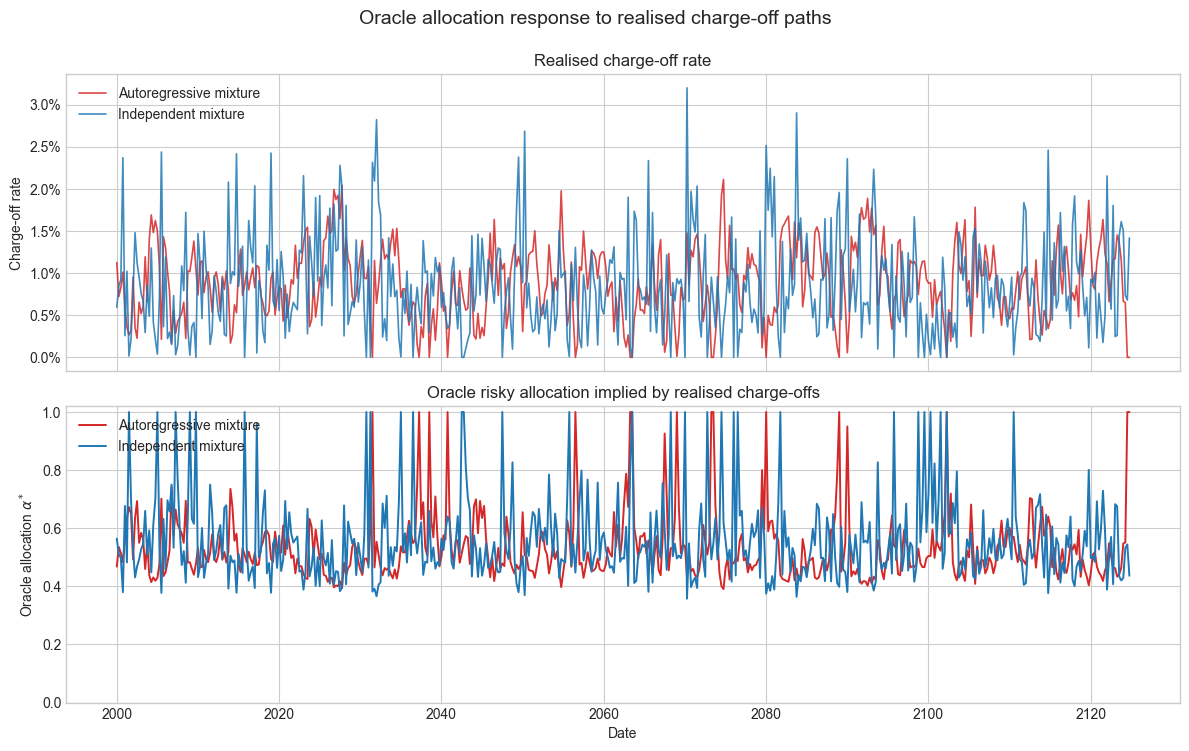

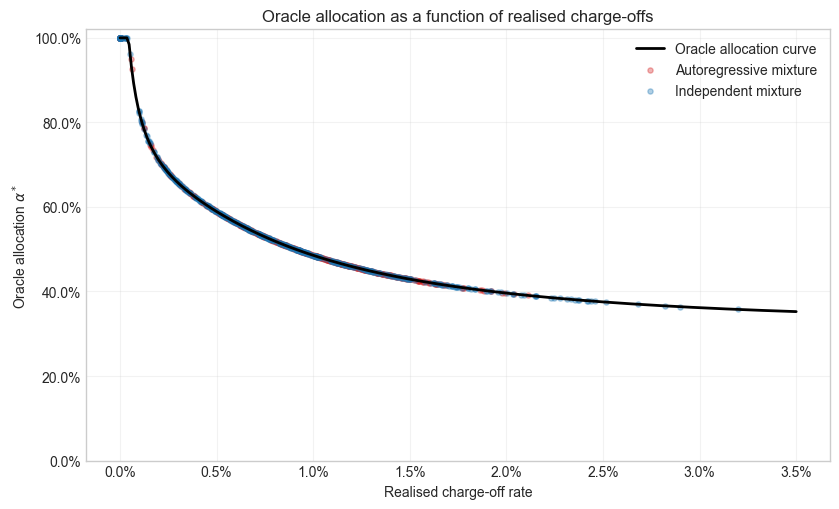

In [152]:
import sys

MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import CapitalConfig, optimise_oracle_alpha

oracle_capital_config = CapitalConfig(lgd=0.45, leverage=10.0)

for diagnostics in [independent_mixture_diagnostics, ar_mixture_diagnostics]:
    diagnostics["oracle_alpha"] = [
        optimise_oracle_alpha(float(c), oracle_capital_config)
        for c in diagnostics["charge_off_rate"]
    ]

oracle_alpha_comparison = pd.concat(
    [independent_mixture_diagnostics, ar_mixture_diagnostics],
    ignore_index=True,
)

display(
    oracle_alpha_comparison.groupby("dgp")[["charge_off_rate", "oracle_alpha"]]
    .agg(["mean", "std", "min", "max"])
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
colors = {"Independent mixture": "tab:blue", "Autoregressive mixture": "tab:red"}

for label, group in oracle_alpha_comparison.groupby("dgp"):
    axes[0].plot(
        group["time"],
        group["charge_off_rate"],
        color=colors[label],
        linewidth=1.2,
        alpha=0.85,
        label=label,
    )
    axes[1].plot(
        group["time"],
        group["oracle_alpha"],
        color=colors[label],
        linewidth=1.4,
        label=label,
    )

axes[0].set_title("Realised charge-off rate")
axes[0].set_ylabel("Charge-off rate")
format_rate_axis(axes[0])
axes[0].legend(loc="upper left")

axes[1].set_title("Oracle risky allocation implied by realised charge-offs")
axes[1].set_ylabel(r"Oracle allocation $\alpha^*$")
axes[1].set_xlabel("Date")
axes[1].set_ylim(0.0, 1.02)
axes[1].legend(loc="upper left")

fig.suptitle("Oracle allocation response to realised charge-off paths", y=0.995, fontsize=14)
fig.tight_layout()
save_current_figure(fig, "figure_6_oracle_alpha_by_chargeoff.png")


chargeoff_grid = np.linspace(
    0.0,
    max(0.035, oracle_alpha_comparison["charge_off_rate"].max() * 1.05),
    300,
)
oracle_alpha_curve = np.array([
    optimise_oracle_alpha(float(c), oracle_capital_config)
    for c in chargeoff_grid
])

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(
    chargeoff_grid,
    oracle_alpha_curve,
    color="black",
    linewidth=2.0,
    label="Oracle allocation curve",
)

for label, group in oracle_alpha_comparison.groupby("dgp"):
    ax.scatter(
        group["charge_off_rate"],
        group["oracle_alpha"],
        s=14,
        alpha=0.35,
        color=colors[label],
        label=label,
    )

ax.set_title("Oracle allocation as a function of realised charge-offs")
ax.set_xlabel("Realised charge-off rate")
ax.set_ylabel(r"Oracle allocation $\alpha^*$")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
format_rate_axis(ax)
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
save_current_figure(fig, "figure_7_oracle_alpha_function_of_chargeoff.png")


## 6. Figure 1: Why the original independent mixture is difficult

Saved models/simulation/figures/dgp_diagnostics/figure_1_independent_mixture_diagnostic.png


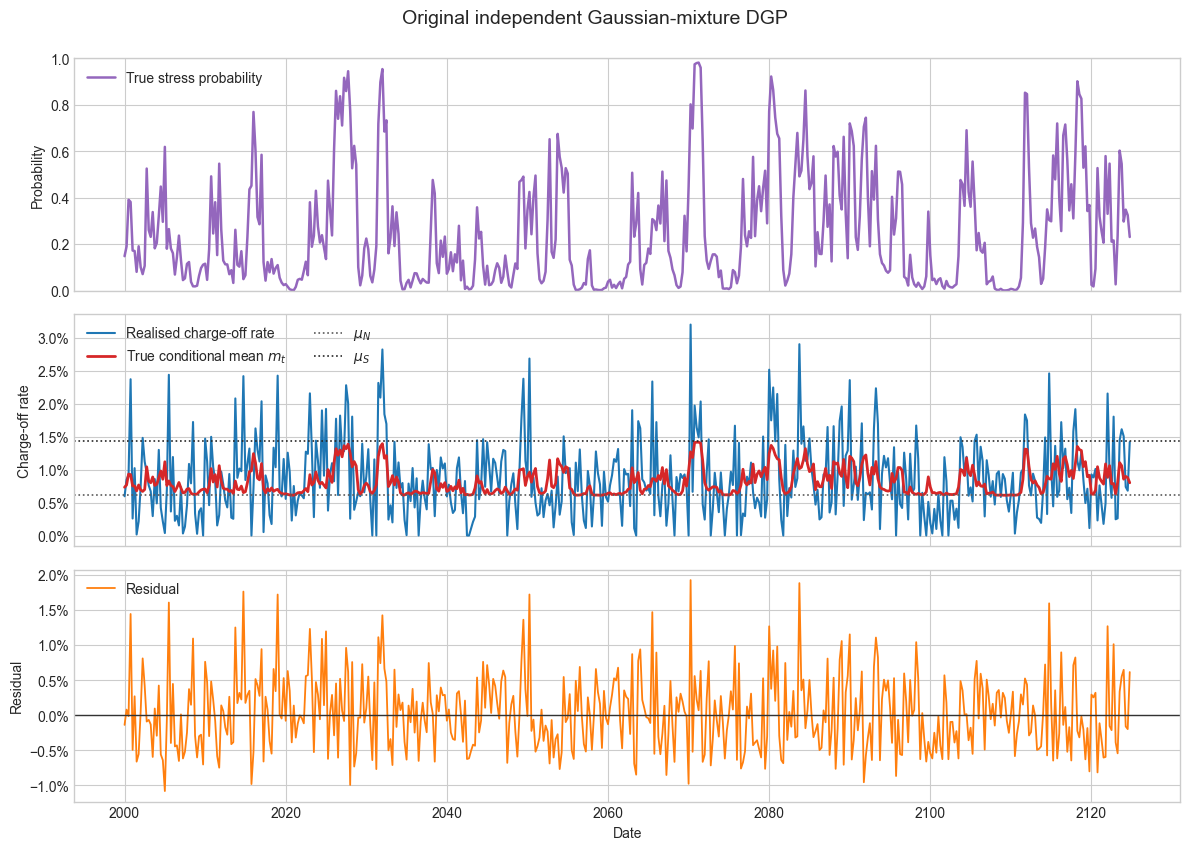

In [153]:
fig, axes = plot_three_panel_diagnostic(
    independent_mixture_diagnostics,
    title="Original independent Gaussian-mixture DGP",
    mean_label="True conditional mean $m_t$",
    filename="figure_1_independent_mixture_diagnostic.png",
    include_macro_target=False,
)

**Interpretation.** In this diagnostic draw, the realised charge-off series has frequent jumps around the smooth conditional mean. The residual panel shows that knowing the true stress probability is not enough to pin down realised charge-offs under the independent mixture, because each quarter still contains mixture-component uncertainty and within-component Gaussian noise.

## 7. Figure 2: Proposed autoregressive mixture

Saved models/simulation/figures/dgp_diagnostics/figure_2_autoregressive_mixture_diagnostic.png


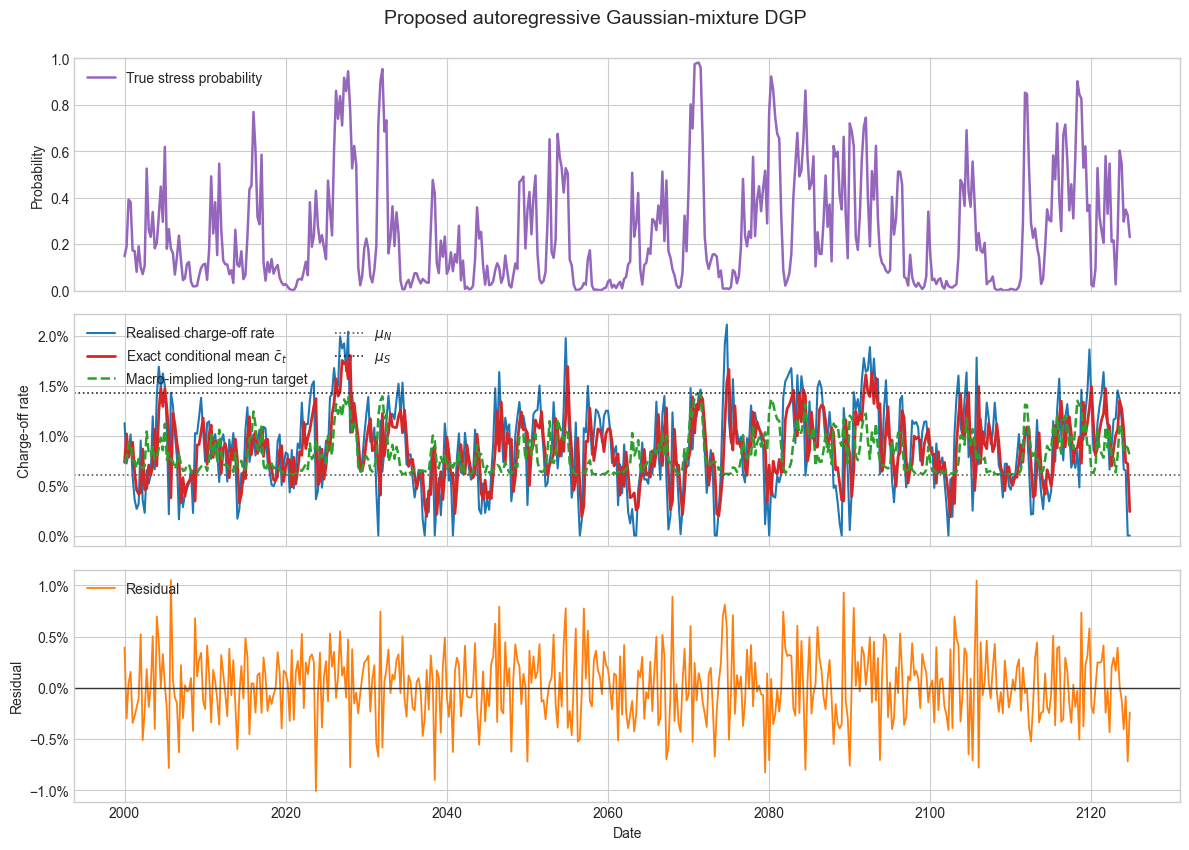

In [154]:
fig, axes = plot_three_panel_diagnostic(
    ar_mixture_diagnostics,
    title="Proposed autoregressive Gaussian-mixture DGP",
    mean_label="Exact conditional mean $\\bar c_t$",
    filename="figure_2_autoregressive_mixture_diagnostic.png",
    include_macro_target=True,
)

**Interpretation.** The autoregressive mixture remains visibly stochastic, but the exact conditional mean moves with lagged realised charge-offs. The dashed macro-implied target is smoother and less reactive, so the gap between the red and green lines shows how persistence changes the one-step predictive information set without removing irreducible mixture noise.

## 8. Figure 3: Direct comparison of the two DGPs

Saved models/simulation/figures/dgp_diagnostics/figure_3_dgp_forecast_error_comparison.png


PosixPath('/Users/hannahokeeffe/Documents/Imperial/DFL_New/models/simulation/figures/dgp_diagnostics/figure_3_dgp_forecast_error_comparison.png')

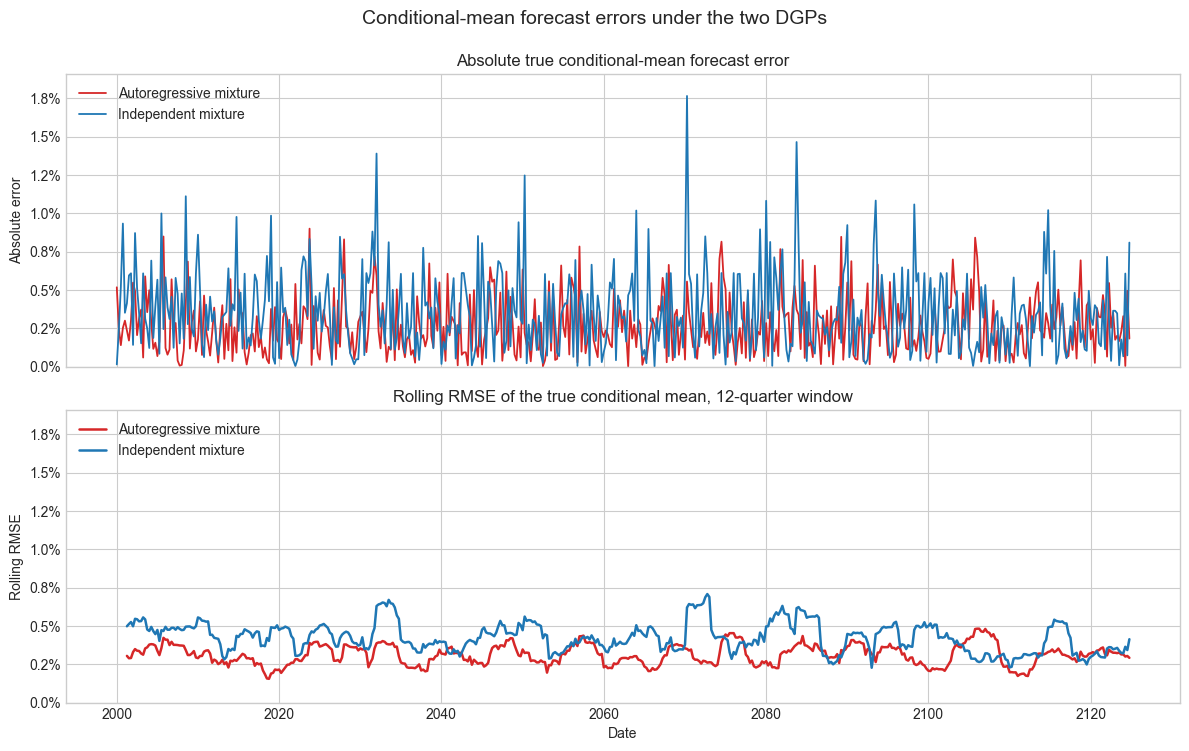

In [145]:
comparison_df = pd.concat(
    [independent_mixture_diagnostics, ar_mixture_diagnostics],
    ignore_index=True,
)
comparison_df["absolute_forecast_error"] = (
    comparison_df["charge_off_rate"] - comparison_df["true_conditional_mean"]
).abs()
comparison_df["squared_forecast_error"] = (
    comparison_df["charge_off_rate"] - comparison_df["true_conditional_mean"]
) ** 2
comparison_df["rolling_rmse_12q"] = comparison_df.groupby("dgp", group_keys=False)["squared_forecast_error"].apply(
    lambda s: np.sqrt(s.rolling(window=12, min_periods=6).mean())
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
colors = {"Independent mixture": "tab:blue", "Autoregressive mixture": "tab:red"}

for label, group in comparison_df.groupby("dgp"):
    axes[0].plot(group["time"], group["absolute_forecast_error"], color=colors[label], linewidth=1.3, label=label)
    axes[1].plot(group["time"], group["rolling_rmse_12q"], color=colors[label], linewidth=1.8, label=label)

axes[0].set_title("Absolute true conditional-mean forecast error")
axes[0].set_ylabel("Absolute error")
format_rate_axis(axes[0])
axes[0].legend(loc="upper left")

axes[1].set_title("Rolling RMSE of the true conditional mean, 12-quarter window")
axes[1].set_ylabel("Rolling RMSE")
axes[1].set_xlabel("Date")
format_rate_axis(axes[1])
axes[1].legend(loc="upper left")

max_error_axis = comparison_df[["absolute_forecast_error", "rolling_rmse_12q"]].max(skipna=True).max()
for ax in axes:
    ax.set_ylim(bottom=0.0, top=max_error_axis * 1.08)

fig.suptitle("Conditional-mean forecast errors under the two DGPs", y=0.995, fontsize=14)
fig.tight_layout()
save_current_figure(fig, "figure_3_dgp_forecast_error_comparison.png")

**Interpretation.** The comparison puts both DGPs on the same error scale. In this run, the autoregressive mixture generally has lower conditional-mean forecast errors because the true conditional mean uses lagged charge-offs, while the independent mixture relies only on the macro-implied mixture mean and therefore produces more abrupt quarter-to-quarter deviations.

## 9. Figure 4: Sensitivity to rho

,rho,1 - rho,maximum macro-driven change,maximum macro-driven change (percentage points)
0,0.000000,1.000000,0.008200,0.820000
1,0.500000,0.500000,0.004100,0.410000
2,0.700000,0.300000,0.002460,0.246000
3,0.850000,0.150000,0.001230,0.123000
4,0.950000,0.050000,0.000410,0.041000


For rho = 0.85, the maximum macro-driven one-step conditional-mean change is 0.123 percentage points.
Saved models/simulation/figures/dgp_diagnostics/figure_4_rho_sensitivity.png


PosixPath('/Users/hannahokeeffe/Documents/Imperial/DFL_New/models/simulation/figures/dgp_diagnostics/figure_4_rho_sensitivity.png')

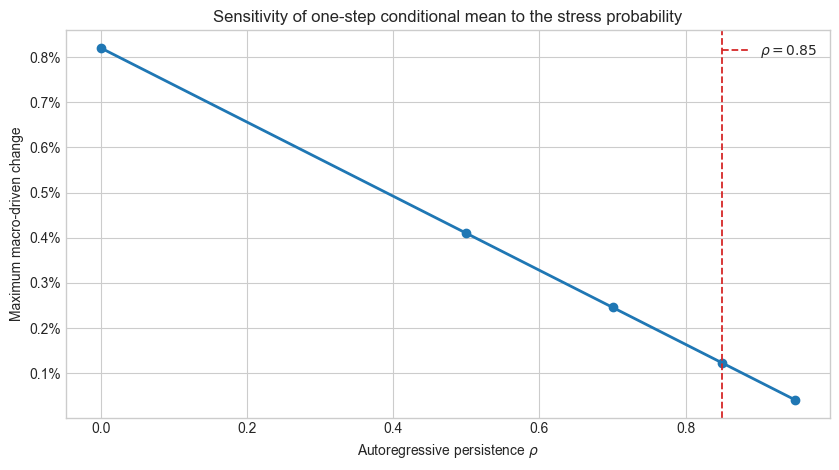

In [117]:
rho_values = [0.0, 0.5, 0.7, 0.85, 0.95]
rho_sensitivity = pd.DataFrame({"rho": rho_values})
rho_sensitivity["1 - rho"] = 1.0 - rho_sensitivity["rho"]
rho_sensitivity["maximum macro-driven change"] = rho_sensitivity["1 - rho"] * (mu_S - mu_N)
rho_sensitivity["maximum macro-driven change (percentage points)"] = 100.0 * rho_sensitivity["maximum macro-driven change"]

display(rho_sensitivity)
rho_085_value = rho_sensitivity.loc[np.isclose(rho_sensitivity["rho"], 0.85), "maximum macro-driven change (percentage points)"].iloc[0]
print(f"For rho = 0.85, the maximum macro-driven one-step conditional-mean change is {rho_085_value:.3f} percentage points.")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    rho_sensitivity["rho"],
    rho_sensitivity["maximum macro-driven change"],
    marker="o",
    linewidth=2.0,
    color="tab:blue",
)
ax.axvline(0.85, color="tab:red", linestyle="--", linewidth=1.3, label="$\\rho = 0.85$")
ax.set_title("Sensitivity of one-step conditional mean to the stress probability")
ax.set_xlabel("Autoregressive persistence $\\rho$")
ax.set_ylabel("Maximum macro-driven change")
format_rate_axis(ax)
ax.legend(loc="upper right")
fig.tight_layout()
save_current_figure(fig, "figure_4_rho_sensitivity.png")

**Interpretation.** The plot declines linearly in $\rho$: as persistence rises, the one-step conditional mean places less weight on the macro-implied mixture target. At $\rho = 0.85$, changing $p_t$ from 0 to 1 can move the one-step conditional mean by only 0.123 percentage points, so very high persistence makes accurate prediction of $p_t$ less influential for the next-quarter mean.

,c_lag,c_lag_percentage_points,rho,alpha_at_p0,alpha_at_p1,alpha_range_over_p
0,0.006100,0.610000,0.000000,0.535257,0.409154,0.126103
1,0.006100,0.610000,0.500000,0.538516,0.455804,0.082712
2,0.006100,0.610000,0.700000,0.542247,0.484764,0.057483
3,0.006100,0.610000,0.850000,0.546904,0.513228,0.033676
4,0.006100,0.610000,0.950000,0.552310,0.538299,0.014011
5,0.008000,0.800000,0.000000,0.535257,0.409154,0.126103
6,0.008000,0.800000,0.500000,0.518197,0.443889,0.074308
7,0.008000,0.800000,0.700000,0.514127,0.464586,0.049541
8,0.008000,0.800000,0.850000,0.512863,0.484646,0.028216
9,0.008000,0.800000,0.950000,0.514084,0.502474,0.011611


Saved models/simulation/figures/dgp_diagnostics/figure_5_alpha_allocation_rho_and_clag_sensitivity.png


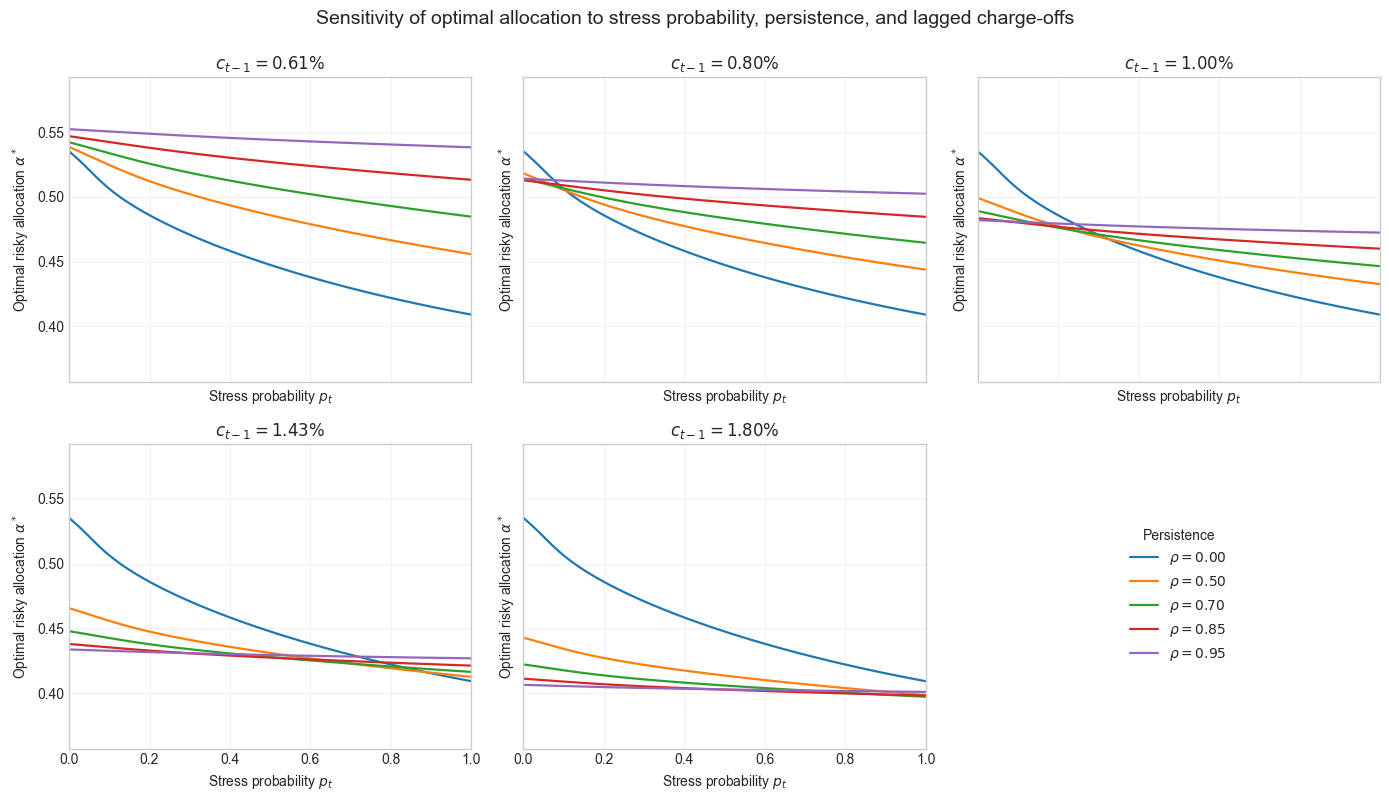

In [118]:
import sys

MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import CapitalConfig, optimise_alpha_from_p

rho_values = [0.0, 0.5, 0.7, 0.85, 0.95]
p_grid = np.linspace(0.0, 1.0, 101)
c_lag_grid = np.array([mu_N, 0.008, 0.010, mu_S, 0.018], dtype=float)
base_capital_config = CapitalConfig(lgd=0.45, leverage=10.0)


def predictive_mixture_parameters(p, c_lag, rho):
    """Parameters of the AR Gaussian-mixture predictive distribution."""
    return {
        "p_stress": float(np.clip(p, 0.0, 1.0)),
        "mu_normal": rho * c_lag + (1.0 - rho) * mu_N,
        "mu_stress": rho * c_lag + (1.0 - rho) * mu_S,
        "sigma_normal": np.sqrt(1.0 - rho**2) * sigma_N,
        "sigma_stress": np.sqrt(1.0 - rho**2) * sigma_S,
    }


def capital_config_for_predictive_distribution(params, cfg=base_capital_config):
    """Keep objective constants fixed while changing mixture parameters."""
    return CapitalConfig(
        lgd=cfg.lgd,
        y_bar=cfg.y_bar,
        lambda_penalty=cfg.lambda_penalty,
        maturity=cfg.maturity,
        leverage=cfg.leverage,
        mu_normal=params["mu_normal"],
        sigma_normal=max(params["sigma_normal"], 1e-10),
        mu_stress=params["mu_stress"],
        sigma_stress=max(params["sigma_stress"], 1e-10),
        pd_floor=cfg.pd_floor,
        pd_cap=cfg.pd_cap,
        alpha_eps=cfg.alpha_eps,
    )


def optimal_alpha_for_distribution(p, c_lag, rho):
    params = predictive_mixture_parameters(p, c_lag, rho)
    cfg = capital_config_for_predictive_distribution(params)
    return optimise_alpha_from_p(params["p_stress"], cfg)


alpha_sensitivity_records = []
alpha_by_c_lag_and_rho = {}

for c_lag_value in c_lag_grid:
    alpha_by_c_lag_and_rho[c_lag_value] = {}
    for rho_value in rho_values:
        alpha_values = np.array([
            optimal_alpha_for_distribution(p_value, c_lag_value, rho_value)
            for p_value in p_grid
        ])
        alpha_by_c_lag_and_rho[c_lag_value][rho_value] = alpha_values
        alpha_sensitivity_records.append(
            {
                "c_lag": c_lag_value,
                "c_lag_percentage_points": 100.0 * c_lag_value,
                "rho": rho_value,
                "alpha_at_p0": alpha_values[0],
                "alpha_at_p1": alpha_values[-1],
                "alpha_range_over_p": alpha_values.max() - alpha_values.min(),
            }
        )

alpha_sensitivity_summary = pd.DataFrame(alpha_sensitivity_records)
display(alpha_sensitivity_summary)

all_alpha_values = np.concatenate([
    values
    for by_rho in alpha_by_c_lag_and_rho.values()
    for values in by_rho.values()
])
alpha_padding = 0.04
alpha_ylim = (
    max(0.0, all_alpha_values.min() - alpha_padding),
    min(1.0, all_alpha_values.max() + alpha_padding),
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for panel, c_lag_value in enumerate(c_lag_grid):
    ax = axes[panel]
    for rho_value in rho_values:
        ax.plot(
            p_grid,
            alpha_by_c_lag_and_rho[c_lag_value][rho_value],
            linewidth=1.6,
            label=fr"$\rho={rho_value:.2f}$",
        )
    ax.set_title(fr"$c_{{t-1}}={100.0 * c_lag_value:.2f}\%$")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(*alpha_ylim)
    ax.grid(True, alpha=0.25)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, title="Persistence", loc="center")

for ax in axes[: len(c_lag_grid)]:
    ax.set_xlabel("Stress probability $p_t$")
    ax.set_ylabel(r"Optimal risky allocation $\alpha^*$")

fig.suptitle(
    "Sensitivity of optimal allocation to stress probability, persistence, and lagged charge-offs",
    y=0.995,
    fontsize=14,
)
fig.tight_layout()
save_current_figure(fig, "figure_5_alpha_allocation_rho_and_clag_sensitivity.png")
plt.show()
